# **Data Science**

**Grupo:**
- Miguel Manfré; RM564233
- Vitor Pallis; RM561962
- João Victor; RM563433
- Gabriel Speck; RM562513
- Brenda Thais; RM561258


# Contextualização do problema:

## Problema escolhido

### *Rastreamento orbital e comportamento de satélites*
Principalmente na distribuição de altitudes, inclinações e excentricidades, identificação de outliers (objetos com comportamento orbital atípico) e detecção de sinais de decaimento orbital ao longo do tempo.

## Relevância do problema

A gestão do tráfego espacial e a mitigação de detritos orbitais são cruciais para a sustentabilidade das operações espaciais. Entender a distribuição de órbitas, identificar satélites em risco de reentrada e detectar padrões de comportamento suporta decisões sobre prevenção de colisões, planejamento de janelas de lançamento, regulação de frequências e investimentos em políticas de mitigação.

## Relação com a economia espacial

Operadores comerciais (telecomunicações, observação da Terra, constelações IoT) dependem de alocação eficiente de órbitas e de previsões confiáveis para reduzir custos e riscos. Insights sobre concentrações orbitais, taxas de decaimento e distribuição por operador ajudam a direcionar investimentos, políticas de responsabilidade e serviços de monitoramento impactando diretamente receita,seguro e estratégias operacionais na economia espacial.

## Objetivo da análise

Obejetivo de aplicar estatística descritiva a dados públicos de um CSV do site KAGGLE para:

- Caracterizar distribuições de altitude, inclinação, excentricidade e período orbital.
- Quantificar variabilidade (desvio padrão, CV) e posição (Q1/Q2/Q3, percentis).
- Detectar outliers usando IQR e/ou Z-score e interpretar causas prováveis (decaimento, manobra, objetos incomuns).

Site referência:
https://www.kaggle.com/datasets/karnikakapoor/satellite-orbital-catalog

# Preparação dos Dados
Utilizaremos as bibliotecas em Python:
- Pandas: leitura, limpeza e manipulação de dados
- Numpy: operações numéricas e cálculo de medidas estatísticas.
- Matplotlib: visualizações estatísticas (histogramas, boxplots, scatter).

In [1]:
%pip install pandas; numpy; matplotlib

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl (12.5 MB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 102.0 MB/s  0:00:00
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 89.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? et

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importação das bibliotecas

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Leitura dos Dados

In [33]:
df = pd.read_csv('./current_catalog.csv')
df.head()

,norad_id,name,object_type,satellite_constellation,altitude_km,altitude_category,orbital_band,congestion_risk,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,orbit_lifetime_category,mean_motion,epoch,data_source,snapshot_date,country,last_seen
0,900,CALSPHERE 1,PAYLOAD,Other,975.928822,Low LEO,LEO-Polar,LOW,90.2236,0.002533,2024,0,<1yr,13.766118,2026-06-06 12:07:29.114112,celestrak,2026-06-06,US,2026-06-06
1,902,CALSPHERE 2,PAYLOAD,Other,1061.609076,Mid LEO,LEO-Polar,LOW,90.2377,0.001656,2024,0,<1yr,13.528997,2026-06-06 01:48:16.784064,celestrak,2026-06-06,US,2026-06-06
2,1361,LCS 1,PAYLOAD,Other,2787.867006,High LEO,MEO,LOW,32.1368,0.001240,2024,1,<1yr,9.893107,2026-06-05 11:00:01.893600,celestrak,2026-06-06,US,2026-06-06
3,1512,TEMPSAT 1,PAYLOAD,Other,1133.239326,Mid LEO,LEO-Polar,HIGH,89.9995,0.006763,2024,0,<1yr,13.335935,2026-06-06 11:36:44.059392,celestrak,2026-06-06,US,2026-06-06
4,1520,CALSPHERE 4A,PAYLOAD,Other,1123.182767,Mid LEO,LEO-Polar,HIGH,89.8976,0.007130,2024,0,<1yr,13.362762,2026-06-06 09:00:02.100384,celestrak,2026-06-06,US,2026-06-06


## Inspeção Estrutural

In [11]:
df.shape

(16188, 19)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16188 entries, 0 to 16187
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   norad_id                 16188 non-null  int64  
 1   name                     16188 non-null  str    
 2   object_type              16187 non-null  str    
 3   satellite_constellation  16188 non-null  str    
 4   altitude_km              16188 non-null  float64
 5   altitude_category        16188 non-null  str    
 6   orbital_band             16188 non-null  str    
 7   congestion_risk          16188 non-null  str    
 8   inclination              16188 non-null  float64
 9   eccentricity             16188 non-null  float64
 10  launch_year_estimate     16188 non-null  int64  
 11  days_in_orbit_estimate   16188 non-null  int64  
 12  orbit_lifetime_category  16188 non-null  str    
 13  mean_motion              16188 non-null  float64
 14  epoch                    16188 no

## Resumo estatístico

In [ ]:
df.describe(percentiles=[0.05,0.25,0.5,0.75,0.95]).T

C:\Users\User\AppData\Local\Temp\ipykernel_20692\652557734.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
name,16188,16184,ELECTRON KICK STAGE R/B,2
object_type,16187,4,PAYLOAD,15574
satellite_constellation,16188,6,Starlink Gen 1,10792
altitude_category,16188,7,Very Low LEO,9618
orbital_band,16188,8,LEO-Inclined,6798
congestion_risk,16188,3,HIGH,13092
orbit_lifetime_category,16188,2,<1yr,16186
epoch,16188,15240,2026-06-06 06:00:02.000160,538
data_source,16188,1,celestrak,16188
snapshot_date,16188,168,2026-06-06,15630


In [ ]:
df.describe(include='object').T

C:\Users\User\AppData\Local\Temp\ipykernel_20692\1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
name,16188,16184,ELECTRON KICK STAGE R/B,2
object_type,16187,4,PAYLOAD,15574
satellite_constellation,16188,6,Starlink Gen 1,10792
altitude_category,16188,7,Very Low LEO,9618
orbital_band,16188,8,LEO-Inclined,6798
congestion_risk,16188,3,HIGH,13092
orbit_lifetime_category,16188,2,<1yr,16186
epoch,16188,15240,2026-06-06 06:00:02.000160,538
data_source,16188,1,celestrak,16188
snapshot_date,16188,168,2026-06-06,15630


## Valores ausentes

In [25]:
missing = df.isnull().sum()
missing_percent = missing / len(df) * 100
pd.concat([missing, missing_percent], axis=1, keys=['missing','percent'])

,missing,percent
norad_id,0,0.000000
name,0,0.000000
object_type,1,0.006177
satellite_constellation,0,0.000000
altitude_km,0,0.000000
altitude_category,0,0.000000
orbital_band,0,0.000000
congestion_risk,0,0.000000
inclination,0,0.000000
eccentricity,0,0.000000


## Duplicatas e identificadores

In [38]:
df.duplicated().sum()
df[df.duplicated(keep=False)].head()
df['norad_id'].nunique(), df['norad_id'].value_counts().head()

(16188,
 norad_id
 900     1
 902     1
 1361    1
 1512    1
 1520    1
 Name: count, dtype: int64)

## Valores inconsistentes

0       2026-06-06 12:07:29.114112
1       2026-06-06 01:48:16.784064
2       2026-06-05 11:00:01.893600
3       2026-06-06 11:36:44.059392
4       2026-06-06 09:00:02.100384
                   ...            
16183   2026-06-06 02:18:04.210848
16184   2026-06-04 15:59:40.712352
16185   2026-06-06 02:49:11.173152
16186   2026-06-06 02:48:25.234272
16187   2026-06-04 22:45:01.755936
Name: epoch, Length: 16188, dtype: datetime64[us]

## Grafico de barras
Quantidade de satélites por país

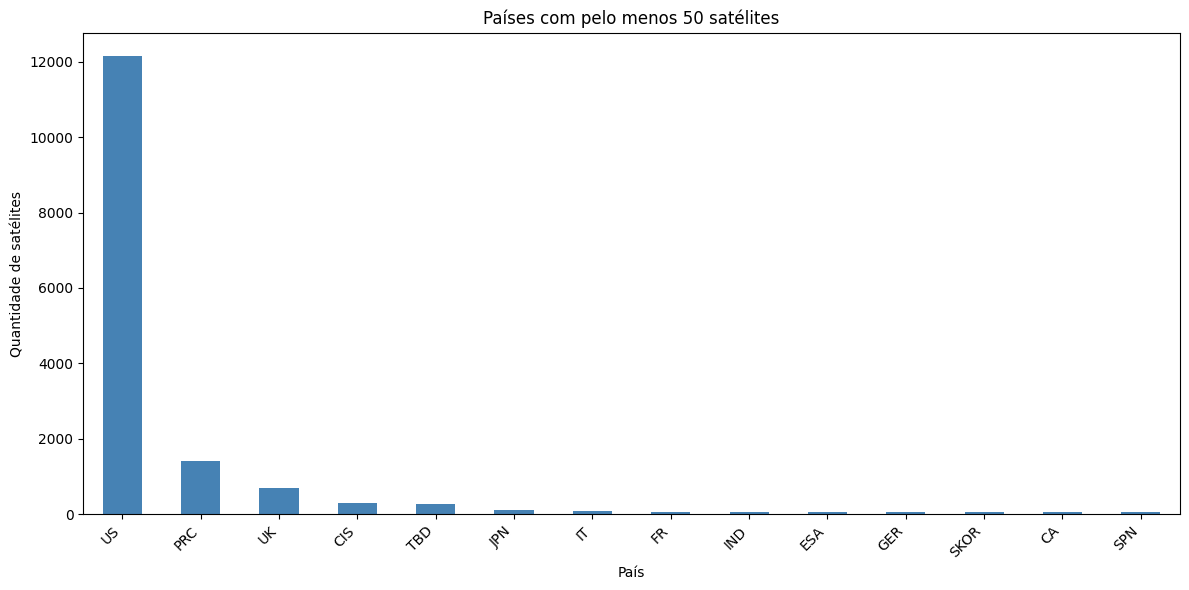

In [ ]:
# 1) Contagem de satélites por país
contagem_pais = df['country'].value_counts()

# 2) Defina o mínimo para aparecer no gráfico
min_sat = 50

# 3) Filtra países com pelo menos min_sat satélites
contagem_filtrada = contagem_pais[contagem_pais >= min_sat].sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(12, 6))
contagem_filtrada.plot(kind='bar', color='steelblue')
plt.title(f'Países com pelo menos {min_sat} satélites')
plt.xlabel('País')
plt.ylabel('Quantidade de satélites')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()